# Data Profiling

## Projeto
Fraud Analytics Platform

## Objetivo

Realizar a análise inicial do dataset IEEE-CIS Fraud Detection, identificando sua estrutura, qualidade dos dados e características gerais que servirão de base para as próximas etapas do projeto.

Nesta etapa serão avaliados:

- Estrutura dos arquivos
- Tipos de dados
- Valores ausentes
- Duplicidades
- Cardinalidade
- Estatísticas descritivas
- Balanceamento da variável alvo

In [16]:
# Bibliotecas

import pandas as pd
import numpy as np
from pathlib import Path

In [17]:
# Configurações do Pandas

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [18]:
# Caminho dos arquivos

project_path = Path("..")

raw_path = project_path / "data" / "raw"

print(raw_path)

..\data\raw


In [19]:
# Listar arquivos

files = sorted(raw_path.glob("*.csv"))

for file in files:
    print(file.name)

sample_submission.csv
test_identity.csv
test_transaction.csv
train_identity.csv
train_transaction.csv


In [5]:
# Ler cabeçalhos

for file in files:
    df = pd.read_csv(file, nrows=5)
    print("="*70)
    print(file.name)
    print("="*70)

    print(df.head())
    print()

sample_submission.csv
   TransactionID  isFraud
0        3663549      0.5
1        3663550      0.5
2        3663551      0.5
3        3663552      0.5
4        3663553      0.5

test_identity.csv
   TransactionID  id-01     id-02  id-03  id-04  id-05  id-06  id-07  id-08  \
0        3663586  -45.0  280290.0    NaN    NaN    0.0    0.0    NaN    NaN   
1        3663588    0.0    3579.0    0.0    0.0    0.0    0.0    NaN    NaN   
2        3663597   -5.0  185210.0    NaN    NaN    1.0    0.0    NaN    NaN   
3        3663601  -45.0  252944.0    0.0    0.0    0.0    0.0    NaN    NaN   
4        3663602  -95.0  328680.0    NaN    NaN    7.0  -33.0    NaN    NaN   

   id-09  id-10  id-11     id-12  id-13  id-14  id-15     id-16  id-17  id-18  \
0    NaN    NaN  100.0  NotFound   27.0    NaN    New  NotFound  225.0   15.0   
1    0.0    0.0  100.0     Found    NaN -300.0  Found     Found  166.0    NaN   
2    NaN    NaN  100.0  NotFound   52.0 -360.0    New  NotFound  225.0    NaN   
3   

In [20]:
# Carga dos datasets

datasets = {}

for file in files:
    print(f"Carregando {file.name}...")

    datasets[file.name] = pd.read_csv(file)

print("\nTodos os arquivos foram carregados com sucesso!")

Carregando sample_submission.csv...
Carregando test_identity.csv...
Carregando test_transaction.csv...
Carregando train_identity.csv...
Carregando train_transaction.csv...

Todos os arquivos foram carregados com sucesso!


In [6]:
# Conferir Dataframes

for name, df in datasets.items():
    print(f"{name:<25} {df.shape}")

sample_submission.csv     (506691, 2)
test_identity.csv         (141907, 41)
test_transaction.csv      (506691, 393)
train_identity.csv        (144233, 41)
train_transaction.csv     (590540, 394)


In [8]:
# Resumo Geral

summary = []

for name, df in datasets.items():
    
    summary.append({
        "Arquivo": name,
        "Linhas": df.shape[0],
        "Colunas": df.shape[1],
        "Memória (MB)": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "Valores Nulos": int(df.isna().sum().sum())
    })

summary_df = pd.DataFrame(summary)
summary_df

,Arquivo,Linhas,Colunas,Memória (MB),Valores Nulos
0,sample_submission.csv,506691,2,7.73,0
1,test_identity.csv,141907,41,154.11,2105385
2,test_transaction.csv,506691,393,1807.74,73490163
3,train_identity.csv,144233,41,157.63,2104107
4,train_transaction.csv,590540,394,2100.70,95566686


In [9]:
# Tipos de dados

for name, df in datasets.items():
    print("=" *80)
    print(name)
    print("=" *80)

    display(df.dtypes.value_counts())

sample_submission.csv


int64      1
float64    1
Name: count, dtype: int64

test_identity.csv


float64    23
str        17
int64       1
Name: count, dtype: int64

test_transaction.csv


float64    376
str         14
int64        3
Name: count, dtype: int64

train_identity.csv


float64    23
str        17
int64       1
Name: count, dtype: int64

train_transaction.csv


float64    376
str         14
int64        4
Name: count, dtype: int64

In [10]:
# Informações gerais

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)

    df.info()

    print()

sample_submission.csv
<class 'pandas.DataFrame'>
RangeIndex: 506691 entries, 0 to 506690
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  506691 non-null  int64  
 1   isFraud        506691 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 7.7 MB

test_identity.csv
<class 'pandas.DataFrame'>
RangeIndex: 141907 entries, 0 to 141906
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  141907 non-null  int64  
 1   id-01          141907 non-null  float64
 2   id-02          136976 non-null  float64
 3   id-03          66481 non-null   float64
 4   id-04          66481 non-null   float64
 5   id-05          134750 non-null  float64
 6   id-06          134750 non-null  float64
 7   id-07          5059 non-null    float64
 8   id-08          5059 non-null    float64
 9   id-09          74338 non-null 

In [11]:
# Valores ausentes

for name, df in datasets.items():

    missing = pd.DataFrame({
        "Nulos": df.isna().sum(),
        "% Nulos": round(df.isna().mean()*100, 2)
    })

    missing = (
        missing
        .query("Nulos > 0")
        .sort_values("Nulos", ascending=False)
    )

    print("=" * 80)
    print(name)
    print("=" * 80)

    display(missing.head(20))

sample_submission.csv


,Nulos,% Nulos


test_identity.csv


,Nulos,% Nulos
id-24,137167,96.66
id-25,136868,96.45
id-26,136860,96.44
id-08,136848,96.43
id-07,136848,96.43
id-21,136848,96.43
id-22,136845,96.43
id-27,136845,96.43
id-23,136845,96.43
id-18,91032,64.15


test_transaction.csv


,Nulos,% Nulos
dist2,470255,92.81
D7,446558,88.13
D12,437437,86.33
D8,432353,85.33
D9,432353,85.33
V154,430906,85.04
V162,430906,85.04
V146,430906,85.04
V149,430906,85.04
V138,430906,85.04


train_identity.csv


,Nulos,% Nulos
id_24,139486,96.71
id_25,139101,96.44
id_07,139078,96.43
id_08,139078,96.43
id_21,139074,96.42
id_26,139070,96.42
id_22,139064,96.42
id_27,139064,96.42
id_23,139064,96.42
id_18,99120,68.72


train_transaction.csv


,Nulos,% Nulos
dist2,552913,93.63
D7,551623,93.41
D13,528588,89.51
D14,528353,89.47
D12,525823,89.04
D6,517353,87.61
D8,515614,87.31
D9,515614,87.31
V154,508595,86.12
V153,508595,86.12


In [12]:
# Verificar registros duplicados

duplicates = []

for name, df in datasets.items():
    qtd_duplicados = df.duplicated().sum()

    duplicates.append({
        "Arquivo": name,
        "Registros": len(df),
        "Duplicados": qtd_duplicados,
        "% Duplicados": round((qtd_duplicados / len(df)) *100, 4)
    })

duplicates_df = pd.DataFrame(duplicates)
duplicates_df

,Arquivo,Registros,Duplicados,% Duplicados
0,sample_submission.csv,506691,0,0.0
1,test_identity.csv,141907,0,0.0
2,test_transaction.csv,506691,0,0.0
3,train_identity.csv,144233,0,0.0
4,train_transaction.csv,590540,0,0.0


In [20]:
# Cardinalidade das colunas

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)

    cardinality = (
        df.nunique()
            .sort_values(ascending=False)
            .to_frame("Valores Distintos")
    )

    print("Maior cardinalidade")
    display(cardinality.head(20))

    print("Menor cardinalidade")
    display(cardinality.tail(20))   


sample_submission.csv
Maior cardinalidade


,Valores Distintos
TransactionID,506691
isFraud,1


Menor cardinalidade


,Valores Distintos
TransactionID,506691
isFraud,1


test_identity.csv
Maior cardinalidade


...

,Valores Distintos
id_22,25
id_14,25
id_03,24
id_18,18
id_04,15
id_24,12
id_32,4
id_34,4
id_23,3
id_15,3


train_transaction.csv
Maior cardinalidade


,Valores Distintos
TransactionID,590540
TransactionDT,573349
V307,37367
V127,24414
V308,23064
TransactionAmt,20902
V310,19136
V306,16210
V317,15184
V203,14951


Menor cardinalidade


,Valores Distintos
V68,3
M4,3
V89,3
V94,3
V88,2
V107,2
V41,2
V65,2
V14,2
V305,2


In [21]:
# Identificar colunas constantes

for name, df in datasets.items():
    constantes = df.columns[df.nunique(dropna=False) <= 1]

    print("=" * 80)
    print(name)
    print("=" * 80)

    if len(constantes) == 0:
        print("Nenhuma coluna constante encontrada.\n")
    else:
        print(f"{len(constantes)} coluna(s) constante(s):")
        print(list(constantes))
        print()

sample_submission.csv
1 coluna(s) constante(s):
['isFraud']

test_identity.csv
Nenhuma coluna constante encontrada.

test_transaction.csv
1 coluna(s) constante(s):
['V107']

train_identity.csv
Nenhuma coluna constante encontrada.

train_transaction.csv
Nenhuma coluna constante encontrada.



In [23]:
# Análise da variável "V107"

print("train_transaction")
display(
    train_transaction["V107"]
    .value_counts(dropna=False)
)

print("\n")

print("test_transaction")
display(
    test_transaction["V107"]
    .value_counts(dropna=False)
)

train_transaction


V107
1.0    589978
NaN       314
0.0       248
Name: count, dtype: int64



test_transaction


V107
1.0    506691
Name: count, dtype: int64

In [15]:
# Estatísticas descritivas

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)

    display(df.describe().T)

sample_submission.csv


,count,mean,std,min,25%,50%,75%,max
TransactionID,506691.0,3916894.0,146269.23696,3663549.0,3790221.5,3916894.0,4043566.5,4170239.0
isFraud,506691.0,0.5,0.00000,0.5,0.5,0.5,0.5,0.5


test_identity.csv


,count,mean,std,min,25%,50%,75%,max
TransactionID,141907.0,3.972166e+06,146996.579622,3663586.0,3859267.5,4001774.0,4105284.5,4170239.0
id-01,141907.0,-1.132573e+01,14.508520,-100.0,-12.5,-5.0,-5.0,0.0
id-02,136976.0,1.926587e+05,182613.277215,2.0,63339.5,133189.5,265717.5,999869.0
id-03,66481.0,5.300763e-02,0.684551,-12.0,0.0,0.0,0.0,11.0
id-04,66481.0,-8.745356e-02,0.840351,-19.0,0.0,0.0,0.0,0.0
id-05,134750.0,1.246033e+00,5.071394,-81.0,0.0,0.0,1.0,52.0
id-06,134750.0,-6.803829e+00,15.921457,-100.0,-6.0,0.0,0.0,0.0
id-07,5059.0,1.249318e+01,11.678206,-41.0,3.0,12.0,21.0,59.0
id-08,5059.0,-3.657778e+01,25.544185,-100.0,-46.0,-33.0,-23.0,0.0
id-09,74338.0,7.621943e-02,1.009687,-32.0,0.0,0.0,0.0,16.0


test_transaction.csv


,count,mean,std,min,25%,50%,75%,max
TransactionID,506691.0,3.916894e+06,1.462692e+05,3.663549e+06,3790221.5,3916894.00,4043566.5,4170239.0
TransactionDT,506691.0,2.692994e+07,4.756507e+06,1.840322e+07,22771540.5,27204658.00,31348560.5,34214345.0
TransactionAmt,506691.0,1.347256e+02,2.457798e+02,1.800000e-02,40.0,67.95,125.0,10270.0
card1,506691.0,9.957222e+03,4.884961e+03,1.001000e+03,6019.0,9803.00,14276.0,18397.0
card2,498037.0,3.637354e+02,1.586887e+02,1.000000e+02,207.0,369.00,512.0,600.0
...,...,...,...,...,...,...,...,...
V335,76431.0,5.833947e+01,9.903611e+02,0.000000e+00,0.0,0.00,0.0,64800.0
V336,76431.0,3.548564e+01,9.040939e+02,0.000000e+00,0.0,0.00,0.0,64800.0
V337,76431.0,9.905876e+01,2.436075e+03,0.000000e+00,0.0,0.00,0.0,375000.0
V338,76431.0,1.555782e+02,4.544304e+03,0.000000e+00,0.0,0.00,0.0,612500.0


train_identity.csv


,count,mean,std,min,25%,50%,75%,max
TransactionID,144233.0,3.236329e+06,178849.571186,2987004.0,3077142.0,3198818.0,3392923.0,3577534.0
id_01,144233.0,-1.017050e+01,14.347949,-100.0,-10.0,-5.0,-5.0,0.0
id_02,140872.0,1.747166e+05,159651.816856,1.0,67992.0,125800.5,228749.0,999595.0
id_03,66324.0,6.018937e-02,0.598231,-13.0,0.0,0.0,0.0,10.0
id_04,66324.0,-5.893794e-02,0.701015,-28.0,0.0,0.0,0.0,0.0
id_05,136865.0,1.615585e+00,5.249856,-72.0,0.0,0.0,1.0,52.0
id_06,136865.0,-6.698710e+00,16.491104,-100.0,-6.0,0.0,0.0,0.0
id_07,5155.0,1.328535e+01,11.384207,-46.0,5.0,14.0,22.0,61.0
id_08,5155.0,-3.860039e+01,26.084899,-100.0,-48.0,-34.0,-23.0,0.0
id_09,74926.0,9.102314e-02,0.983842,-36.0,0.0,0.0,0.0,25.0


train_transaction.csv


,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
V335,82351.0,5.916455e+01,3.876295e+02,0.000,0.000,0.000,0.00,5.512500e+04
V336,82351.0,2.853090e+01,2.745769e+02,0.000,0.000,0.000,0.00,5.512500e+04
V337,82351.0,5.535242e+01,6.684868e+02,0.000,0.000,0.000,0.00,1.040600e+05
V338,82351.0,1.511605e+02,1.095034e+03,0.000,0.000,0.000,0.00,1.040600e+05


In [16]:
# Análise da variável alvo (isFraud)

train_transaction = datasets["train_transaction.csv"]
fraudes = train_transaction["isFraud"].value_counts().sort_index()

fraudes

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [17]:
# Análise de Balanceamento da variável alvo

percentual = (
    train_transaction["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_index()
)

percentual

isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64

In [18]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


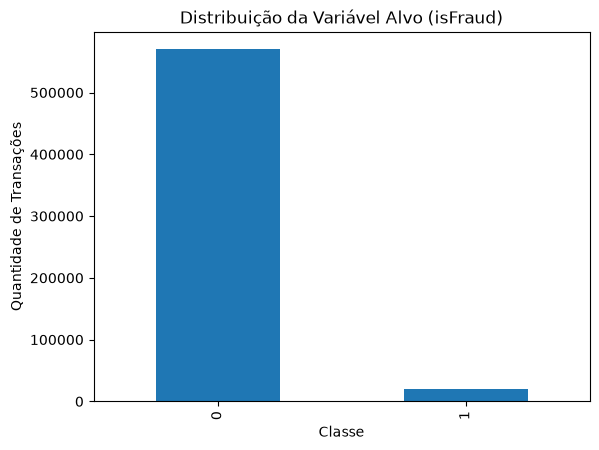

In [19]:
# Distribuição da variável alvo

train_transaction["isFraud"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribuição da Variável Alvo (isFraud)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Transações")

plt.show()

## Relacionamento entre os arquivos

In [7]:
# Separa os Dataframes

train_transaction = datasets["train_transaction.csv"]
train_identity = datasets["train_identity.csv"]

test_transaction = datasets["test_transaction.csv"]
test_identity = datasets["test_identity.csv"]

In [9]:
# Verifica a chave

for name, df in datasets.items():

    print("=" *80)
    print(name)
    print("=" *80)

    if "TransactionID" in df.columns:
        print("✓ TransactionID encontrada")
    else:
        print("✗ TransactionID não encontrada")

    print(f"Quantidade de registros: {len(df):,}")
    print(f"Quantidade de colunas: {df.shape[1]}")
    print()

sample_submission.csv
✓ TransactionID encontrada
Quantidade de registros: 506,691
Quantidade de colunas: 2

test_identity.csv
✓ TransactionID encontrada
Quantidade de registros: 141,907
Quantidade de colunas: 41

test_transaction.csv
✓ TransactionID encontrada
Quantidade de registros: 506,691
Quantidade de colunas: 393

train_identity.csv
✓ TransactionID encontrada
Quantidade de registros: 144,233
Quantidade de colunas: 41

train_transaction.csv
✓ TransactionID encontrada
Quantidade de registros: 590,540
Quantidade de colunas: 394



### Interpretação

Todos os arquivos do dataset possuem a coluna `TransactionID`.

No entanto, cada arquivo desempenha um papel diferente:

- **train_transaction.csv**: transações utilizadas para treinamento do modelo.
- **train_identity.csv**: informações complementares de identidade das transações de treinamento.
- **test_transaction.csv**: transações utilizadas para geração das previsões.
- **test_identity.csv**: informações complementares das transações de teste.
- **sample_submission.csv**: modelo de arquivo para submissão das previsões na competição do Kaggle, contendo apenas `TransactionID` e `isFraud`.

In [10]:
# Verifica se TransactionID é única

for name, df in datasets.items():

    if "TransactionID" in df.columns:
        print("=" * 70)
        print(name)

        print(f"Registros........: {len(df):,}")
        print(f"IDs distintos....: {df['TransactionID'].nunique():,}")

        if len(df) == df["TransactionID"].nunique():
            print("✓ TransactionID é chave única")
        else:
            print("⚠ Existem TransactionIDs duplicados")

sample_submission.csv
Registros........: 506,691
IDs distintos....: 506,691
✓ TransactionID é chave única
test_identity.csv
Registros........: 141,907
IDs distintos....: 141,907
✓ TransactionID é chave única
test_transaction.csv
Registros........: 506,691
IDs distintos....: 506,691
✓ TransactionID é chave única
train_identity.csv
Registros........: 144,233
IDs distintos....: 144,233
✓ TransactionID é chave única
train_transaction.csv
Registros........: 590,540
IDs distintos....: 590,540
✓ TransactionID é chave única


In [12]:
# Analisa o relacionamento entre as tabelas

# Cria cópia da tabela identidade
train_identity_aux = train_identity.copy()

# Indicador de existência da identidade
train_identity_aux["possui_identidade"] = True

# Realiza o LEFT JOIN
train_full = train_transaction.merge(
    train_identity_aux,
    on="TransactionID",
    how="left"
)

# Transações sem correspondência recebem False
train_full["possui_identidade"] = (
    train_full["possui_identidade"]
    .fillna(False)
)

print("JOIN realizado com sucesso.")

JOIN realizado com sucesso.


In [13]:
# Resumo do JOIN

print(f"Transações.............: {len(train_transaction):,}")
print(f"Registros de identidade: {len(train_identity):,}")
print(f"Após LEFT JOIN.........: {len(train_full):,}")

Transações.............: 590,540
Registros de identidade: 144,233
Após LEFT JOIN.........: 590,540


In [14]:
# Analisa correspondência entre transações e identidade

correspondencia = (
    train_full["possui_identidade"]
    .value_counts()
    .rename_axis("Possui identidade")
    .to_frame("Quantidade")
)

display(correspondencia)

,Quantidade
Possui identidade,
False,446307
True,144233


In [15]:
# Percentual de correspondência

percentual = (
    train_full["possui_identidade"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("Possui identidade")
    .to_frame("%")
)

display(percentual)

,%
Possui identidade,
False,75.58
True,24.42


## Interpretação do relacionamento entre as tabelas

A análise demonstrou que:

- `train_transaction` contém todas as transações do conjunto de treinamento.
- `train_identity` possui informações complementares apenas para parte dessas transações.
- O relacionamento entre as tabelas é realizado pela chave `TransactionID`.
- A chave é única em ambas as tabelas, caracterizando um relacionamento **1:1 opcional**.
- Aproximadamente 24% das transações possuem informações de identidade, enquanto cerca de 76% não possuem registro correspondente.

# Conclusões

A etapa de Data Profiling permitiu compreender a estrutura do dataset IEEE-CIS Fraud Detection e identificar aspectos que influenciarão as próximas fases do projeto.

Principais conclusões:

- O dataset é composto por cinco arquivos.
- Os arquivos de transações concentram o maior volume de dados.
- A chave `TransactionID` é única e permite integrar os arquivos de transações e identidade.
- O relacionamento entre transações e identidade é do tipo **1:1 opcional**.
- Foram identificadas colunas com elevado percentual de valores ausentes.
- A variável alvo (`isFraud`) apresenta forte desbalanceamento.
- As descobertas orientarão a construção do processo de ETL, da modelagem analítica e dos modelos de Machine Learning.